In [ ]:
import nltk
import polars as pl
from nltk.corpus import stopwords

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

In [ ]:
df = pl.read_parquet("../data/dataset_small.parquet")

In [145]:
corpus = df.with_columns(
    pl.col("content_clean")
    .str.to_lowercase()
    .str.replace_all(r"\b(" + "|".join(set(stopwords.words("english"))) + r")\b", "")
    .str.replace_all(r"\s+", " ")
    .str.strip_chars()
    .alias("harmonized_content")
)

# Klassenfilter als Kuchendiagram argurmentieren. Wir haben 5 Klassen mit insgesamt mehr als 50% gewählt!

corpus = (corpus
    .filter(pl.col("emotion").is_in(["worry", "hapiness", "sadness", "love"]))
    .filter((pl.col("content_clean") == "").not_())
).select("tweet_id", "emotion", "content", "content_clean", "harmonized_content")

corpus

tweet_id,emotion,content,content_clean,harmonized_content
u32,str,str,str,str
1,"""sadness""","""Layin n bed with a headache u…","""layin n bed with a headache ug…","""layin n bed headache ughhhhwai…"
2,"""sadness""","""Funeral ceremony...gloomy frid…","""funeral ceremonygloomy friday""","""funeral ceremonygloomy friday"""
5,"""worry""","""Re-pinging @ghostridah14: why …","""repinging why didnt you go to …","""repinging didnt go prom bc bf …"
6,"""sadness""","""I should be sleep, but im not!…","""i should be sleep but im not t…","""sleep im thinking old friend w…"
7,"""worry""","""Hmmm. http://www.djhero.com/ i…","""hmmm is down""","""hmmm"""
…,…,…,…,…
39978,"""worry""","""@givemestrength bloody Feds, t…","""bloody feds they lost last sta…","""bloody feds lost last statemen…"
39989,"""love""","""His snoring is so annoying n i…","""his snoring is so annoying n i…","""snoring annoying n keeps sleep…"
39996,"""love""","""Happy Mothers Day All my love""","""happy mothers day all my love""","""happy mothers day love"""


In [146]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(corpus["harmonized_content"])
y = corpus["emotion"]

print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 126500 stored elements and shape (17457, 19374)>
  Coords	Values
  (0, 9227)	1
  (0, 1496)	1
  (0, 7346)	1
  (0, 17696)	1
  (0, 2490)	1
  (1, 6362)	1
  (1, 2749)	1
  (1, 6243)	1
  (2, 13874)	1
  (2, 4401)	2
  (2, 6705)	1
  (2, 12969)	1
  (2, 1426)	1
  (2, 1641)	1
  (2, 9404)	1
  (2, 6261)	1
  (3, 15279)	1
  (3, 8064)	1
  (3, 16808)	1
  (3, 11657)	1
  (3, 6254)	1
  (3, 18328)	1
  (3, 7504)	1
  (3, 10081)	1
  (3, 3965)	1
  :	:
  (17454, 9700)	1
  (17454, 7245)	1
  (17454, 4057)	1
  (17454, 10770)	1
  (17455, 7245)	1
  (17455, 18831)	1
  (17455, 9987)	1
  (17455, 19250)	1
  (17455, 4057)	2
  (17455, 9602)	1
  (17455, 15516)	1
  (17455, 10638)	1
  (17455, 10770)	1
  (17455, 10646)	1
  (17456, 16909)	1
  (17456, 15147)	1
  (17456, 17300)	1
  (17456, 17104)	1
  (17456, 18183)	1
  (17456, 8516)	1
  (17456, 6586)	1
  (17456, 2305)	1
  (17456, 18012)	1
  (17456, 6434)	1
  (17456, 6725)	1


In [147]:
print(vectorizer.get_feature_names_out().shape[0])

19374


Vergleichen Sie verschiedene Modelle und erstellen Sie Visualisierungen bzgl. Test- und Trainingsfehler (y-Achse) und Modellen (x-Achse). Verändern Sie bspw. die berücksichtigten Inputvariablen.

In [148]:
vectorizer = CountVectorizer(max_features=1000)
model = KNeighborsClassifier(n_neighbors=21)

X = vectorizer.fit_transform(corpus["harmonized_content"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model.fit(X_train, y_train)
print("F1-Score (weighted, train): " + str(f1_score(y_train, model.predict(X_train), average="weighted")))
print("F1-Score (weighted, test): " + str(f1_score(y_test, model.predict(X_test), average="weighted")))
print("F1-Score (macro, train): " + str(f1_score(y_train, model.predict(X_train), average="macro")))
print("F1-Score (macro, test): " + str(f1_score(y_test, model.predict(X_test), average="macro")))





F1-Score (weighted, train): 0.5618296306791772
F1-Score (weighted, test): 0.5162190823111126
F1-Score (macro, train): 0.5379644071217596
F1-Score (macro, test): 0.48935692490756955


In [149]:
feature_counts = [50, 100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]
k_values_grid = [3, 5, 7, 11, 15, 21, 31, 51, 71, 97]

train_matrix = np.zeros((len(k_values_grid), len(feature_counts)))
test_matrix = np.zeros((len(k_values_grid), len(feature_counts)))

for j, max_feat in enumerate(feature_counts):
    vectorizer = CountVectorizer(max_features=max_feat)
    X = vectorizer.fit_transform(corpus["harmonized_content"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    for i, k in enumerate(k_values_grid):
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        train_matrix[i, j] = f1_score(y_train, model.predict(X_train), average="macro")
        test_matrix[i, j] = f1_score(y_test, model.predict(X_test), average="macro")

best_idx = np.unravel_index(np.argmax(test_matrix), test_matrix.shape)
best_max_features = feature_counts[best_idx[1]]
best_k = k_values_grid[best_idx[0]]

print(f"Best: max_features={best_max_features}, k={best_k}  (test F1 = {test_matrix[best_idx]:.4f})")

Best: max_features=200, k=21  (test F1 = 0.5157)


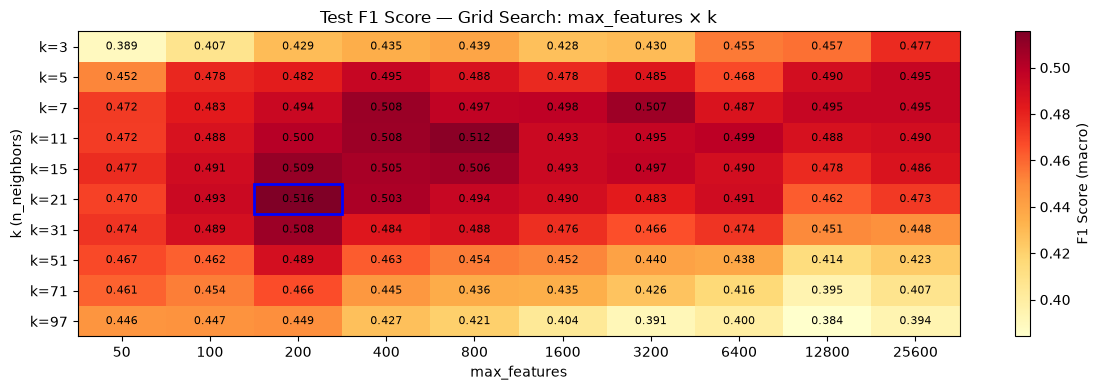

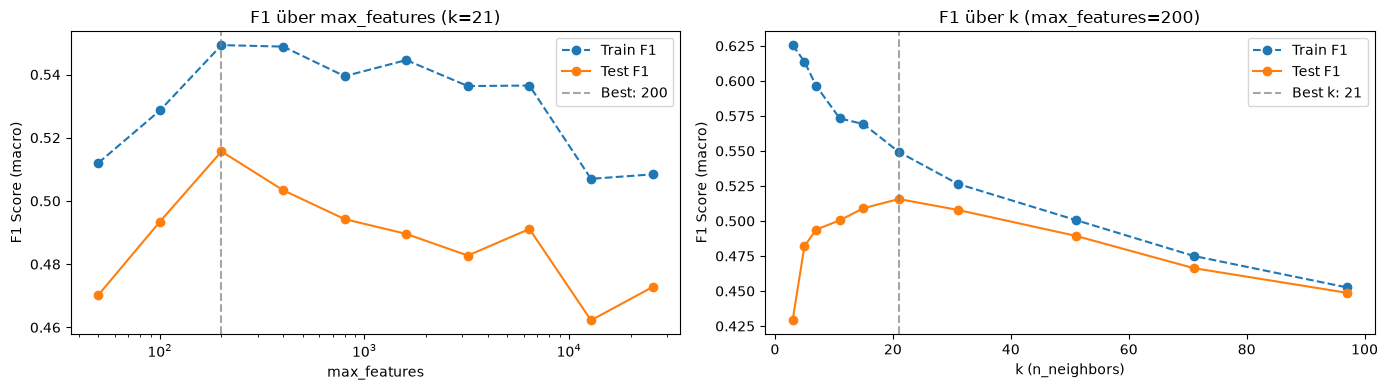

In [150]:
# Heatmap
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(test_matrix, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(feature_counts)))
ax.set_xticklabels(feature_counts)
ax.set_yticks(range(len(k_values_grid)))
ax.set_yticklabels([f"k={k}" for k in k_values_grid])
ax.set_xlabel("max_features")
ax.set_ylabel("k (n_neighbors)")
ax.set_title("Test F1 Score — Grid Search: max_features × k")
for i in range(len(k_values_grid)):
    for j in range(len(feature_counts)):
        ax.text(j, i, f"{test_matrix[i, j]:.3f}", ha="center", va="center", fontsize=8)
ax.add_patch(plt.Rectangle(
    (best_idx[1] - 0.5, best_idx[0] - 0.5), 1, 1,
    fill=False, edgecolor="blue", linewidth=2
))
plt.colorbar(im, ax=ax, label="F1 Score (macro)")
plt.tight_layout()
plt.show()

# F1 over max_features (slice at best k) + F1 over k (slice at best max_features)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(feature_counts, train_matrix[best_idx[0]], linestyle="--", marker="o", color="tab:blue", label="Train F1")
axes[0].plot(feature_counts, test_matrix[best_idx[0]], linestyle="-", marker="o", color="tab:orange", label="Test F1")
axes[0].axvline(best_max_features, color="gray", linestyle="--", alpha=0.7, label=f"Best: {best_max_features}")
axes[0].set_xscale("log")
axes[0].set_xlabel("max_features")
axes[0].set_ylabel("F1 Score (macro)")
axes[0].set_title(f"F1 über max_features (k={best_k})")
axes[0].legend()

axes[1].plot(k_values_grid, train_matrix[:, best_idx[1]], linestyle="--", marker="o", color="tab:blue", label="Train F1")
axes[1].plot(k_values_grid, test_matrix[:, best_idx[1]], linestyle="-", marker="o", color="tab:orange", label="Test F1")
axes[1].axvline(best_k, color="gray", linestyle="--", alpha=0.7, label=f"Best k: {best_k}")
axes[1].set_xlabel("k (n_neighbors)")
axes[1].set_ylabel("F1 Score (macro)")
axes[1].set_title(f"F1 über k (max_features={best_max_features})")
axes[1].legend()

plt.tight_layout()
plt.show()

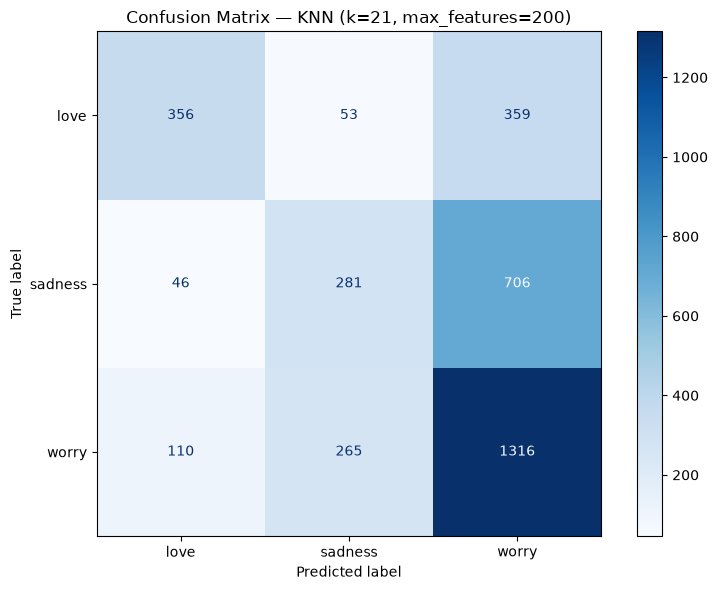

In [152]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

vectorizer = CountVectorizer(max_features=best_max_features)
X = vectorizer.fit_transform(corpus["harmonized_content"])
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

labels = sorted(y.unique().to_list())
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Confusion Matrix — KNN (k={best_k}, max_features={best_max_features})")
plt.tight_layout()
plt.show()